# Spotify Playlist Data - Exploratory Data Analysis

**Author:** Mike Stanton  
**Date:** November 15, 2025  
**Purpose:** Initial exploration of the Spotify playlist dataset to understand user listening habits and playlist patterns for building a music recommender system.

## Dataset Overview
This analysis focuses on the Spotify playlist dataset containing:
- User IDs (hashed usernames)
- Artist names
- Track names  
- Playlist names



## 1. Import Required Libraries

In [22]:
# Install required packages if not available
import sys
!{sys.executable} -m pip install kagglehub pandas numpy matplotlib seaborn plotly

print("Packages installed successfully!")

In [23]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Data loading utilities
import zipfile
import os
import kagglehub

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [24]:
# Recommendation system libraries
from scipy.sparse import csr_matrix
from sklearn.metrics import mean_squared_error

# Install implicit if not available
import subprocess
import sys

print("Checking for implicit library...")
try:
    import implicit
    print(" implicit library is already available!")
except ImportError:
    print(" implicit library not found. Installing...")
    try:
        # Try installing with pip
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'implicit'])
        print(" implicit library installed via pip!")
        
        # Try importing again
        import implicit
        print(" implicit library imported successfully!")
        
    except Exception as e:
        print(f" Installation failed: {e}")
        print(" Please try manually installing with: pip install implicit")
        print(" Or try: conda install -c conda-forge implicit")
        raise ImportError("Could not install implicit library")

Checking for implicit library...
 implicit library is already available!


## 2. Data Loading

Load the Spotify playlist dataset with robust error handling for different file formats and encodings.

In [25]:
# Download the dataset using kagglehub
dataset_path = kagglehub.dataset_download("andrewmvd/spotify-playlists")
print(f"Dataset downloaded to: {dataset_path}")

# Find the CSV file (it might be in a ZIP)
csv_files = []
zip_files = []

for file in os.listdir(dataset_path):
    file_path = os.path.join(dataset_path, file)
    if file.lower().endswith('.csv'):
        csv_files.append(file_path)
    elif file.lower().endswith('.zip'):
        zip_files.append(file_path)

print(f"Found {len(csv_files)} CSV files and {len(zip_files)} ZIP files")

Dataset downloaded to: C:\Users\mstan\.cache\kagglehub\datasets\andrewmvd\spotify-playlists\versions\1
Found 1 CSV files and 0 ZIP files


In [26]:
# Load the data with robust error handling
df = None

if csv_files:
    # Direct CSV file found
    csv_file = csv_files[0]
    print(f"Loading CSV file: {csv_file}")
    try:
        df = pd.read_csv(
            csv_file,
            encoding='iso-8859-1',  # Permissive encoding
            sep=',',
            quotechar='"',
            escapechar='\\',
            engine='python',
            on_bad_lines='skip'
        )
    except Exception as e:
        print(f"Error loading CSV directly: {e}")

elif zip_files:
    # Extract and load from ZIP file
    zip_file = zip_files[0]
    print(f"Extracting from ZIP file: {zip_file}")
    try:
        with zipfile.ZipFile(zip_file, 'r') as z:
            csv_name = next((n for n in z.namelist() if n.lower().endswith('.csv')), None)
            if csv_name:
                print(f"Found CSV in ZIP: {csv_name}")
                with z.open(csv_name) as f:
                    df = pd.read_csv(
                        f,
                        encoding='iso-8859-1',
                        sep=',',
                        quotechar='"',
                        escapechar='\\',
                        engine='python',
                        on_bad_lines='skip'
                    )
            else:
                print("No CSV file found in ZIP archive")
    except Exception as e:
        print(f"Error extracting from ZIP: {e}")

if df is not None:
    print(f"Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
else:
    print("Failed to load dataset")

Loading CSV file: C:\Users\mstan\.cache\kagglehub\datasets\andrewmvd\spotify-playlists\versions\1\spotify_dataset.csv
Dataset loaded successfully!
Shape: (12791243, 4)
Columns: ['user_id', ' "artistname"', ' "trackname"', ' "playlistname"']


In [27]:
# Debug: Check actual column names
if df is not None:
    print("Actual column names in the dataset:")
    for i, col in enumerate(df.columns):
        print(f"{i}: '{col}'")
    print(f"\nDataset shape: {df.shape}")
else:
    print("Dataset is None - loading failed")

Actual column names in the dataset:
0: 'user_id'
1: ' "artistname"'
2: ' "trackname"'
3: ' "playlistname"'

Dataset shape: (12791243, 4)


In [28]:
# Clean column names - remove extra spaces and quotes
if df is not None:
    print("Cleaning column names...")
    print("Before:", list(df.columns))
    
    # Strip spaces and quotes from column names
    df.columns = [col.strip().strip('"') for col in df.columns]
    
    print("After:", list(df.columns))
    print("Column names cleaned successfully!")

Cleaning column names...
Before: ['user_id', ' "artistname"', ' "trackname"', ' "playlistname"']
After: ['user_id', 'artistname', 'trackname', 'playlistname']
Column names cleaned successfully!


## 3. Initial Data Exploration

In [29]:
# Display first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,user_id,artistname,trackname,playlistname
0,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello,(The Angels Wanna Wear My) Red Shoes,HARD ROCK 2010
1,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello & The Attractions,"(What's So Funny 'Bout) Peace, Love And Unders...",HARD ROCK 2010
2,9cc0cfd4d7d7885102480dd99e7a90d6,Tiffany Page,7 Years Too Late,HARD ROCK 2010
3,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello & The Attractions,Accidents Will Happen,HARD ROCK 2010
4,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello,Alison,HARD ROCK 2010


In [30]:
# Basic dataset information
print("Dataset Info:")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nColumn data types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset Info:
Number of rows: 12,791,243
Number of columns: 4
Memory usage: 3390.16 MB

Column data types:
user_id         object
artistname      object
trackname       object
playlistname    object
dtype: object

Missing values:
user_id             0
artistname      33536
trackname          88
playlistname       41
dtype: int64


## 4. Summary Statistics

Calculate key metrics about users, artists, tracks, and playlists.

In [31]:
# Key statistics
stats = {
    'Total Records': df.shape[0],
    'Unique Users': df['user_id'].nunique() if 'user_id' in df.columns else 'N/A',
    'Unique Artists': df['artistname'].nunique() if 'artistname' in df.columns else 'N/A',
    'Unique Tracks': df['trackname'].nunique() if 'trackname' in df.columns else 'N/A',
    'Unique Playlists': df['playlistname'].nunique() if 'playlistname' in df.columns else 'N/A'
}

for key, value in stats.items():
    print(f"{key}: {value:,}" if isinstance(value, int) else f"{key}: {value}")

Total Records: 12,791,243
Unique Users: 15,910
Unique Artists: 287,438
Unique Tracks: 1,999,879
Unique Playlists: 156,884


## 5. Data Visualization

Create visualizations to understand the data distribution and patterns.

In [32]:
# Install networkx for graph visualization
import sys
!{sys.executable} -m pip install networkx

print("NetworkX installed successfully!")

NetworkX installed successfully!


In [33]:
# Import network analysis library
import networkx as nx
from collections import defaultdict
import random

print("Ready to create network graphs!")

Ready to create network graphs!


In [54]:
# Sample the data for network analysis
print("Sampling data for network visualization...")

# Get random users instead of most active users
N_USERS = 100  # Adjust this number based on performance
all_users = df['user_id'].unique()
np.random.seed(42)  # For reproducible results
random_users = np.random.choice(all_users, size=min(N_USERS, len(all_users)), replace=False).tolist()

# Get activity stats for comparison
user_track_counts = df['user_id'].value_counts()
selected_user_counts = user_track_counts[random_users]

print(f"Selected {len(random_users)} random users")
print(f"Random users track counts - Min: {selected_user_counts.min()}, Max: {selected_user_counts.max()}, Avg: {selected_user_counts.mean():.1f}")
print(f"For comparison, most active user has {user_track_counts.iloc[0]} tracks, least active has {user_track_counts.iloc[-1]} tracks")

# Filter data to only include these users
df_sample = df[df['user_id'].isin(random_users)].copy()
print(f"Sample dataset shape: {df_sample.shape}")
print(f"Sample contains {df_sample['user_id'].nunique()} unique users and {df_sample['trackname'].nunique()} unique tracks")

Sampling data for network visualization...
Selected 100 random users
Random users track counts - Min: 1, Max: 9567, Avg: 812.7
For comparison, most active user has 294969 tracks, least active has 1 tracks
Sample dataset shape: (81271, 4)
Sample contains 100 unique users and 57281 unique tracks


In [55]:
# Create user-track relationships and find shared tracks
print("Creating user similarity network...")

# Create a dictionary: track -> set of users who have that track
track_to_users = defaultdict(set)
for _, row in df_sample.iterrows():
    track_to_users[row['trackname']].add(row['user_id'])

print(f"Found {len(track_to_users)} unique tracks in sample")

# Create graph where nodes are users and edges represent shared tracks
G = nx.Graph()

# Add all users as nodes
G.add_nodes_from(random_users)

# Add edges between users who share tracks
shared_tracks_count = defaultdict(int)
for track, users in track_to_users.items():
    users_list = list(users)
    # Create edges between every pair of users who share this track
    for i in range(len(users_list)):
        for j in range(i + 1, len(users_list)):
            user1, user2 = users_list[i], users_list[j]
            shared_tracks_count[(user1, user2)] += 1

# Only add edges if users share multiple tracks (to reduce noise)
MIN_SHARED_TRACKS = 2  # Minimum number of shared tracks to create an edge
for (user1, user2), count in shared_tracks_count.items():
    if count >= MIN_SHARED_TRACKS:
        G.add_edge(user1, user2, weight=count, shared_tracks=count)

print(f"Network created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
print(f"Edges represent users who share at least {MIN_SHARED_TRACKS} tracks")

Creating user similarity network...
Found 57281 unique tracks in sample
Network created with 100 nodes and 1849 edges
Edges represent users who share at least 2 tracks


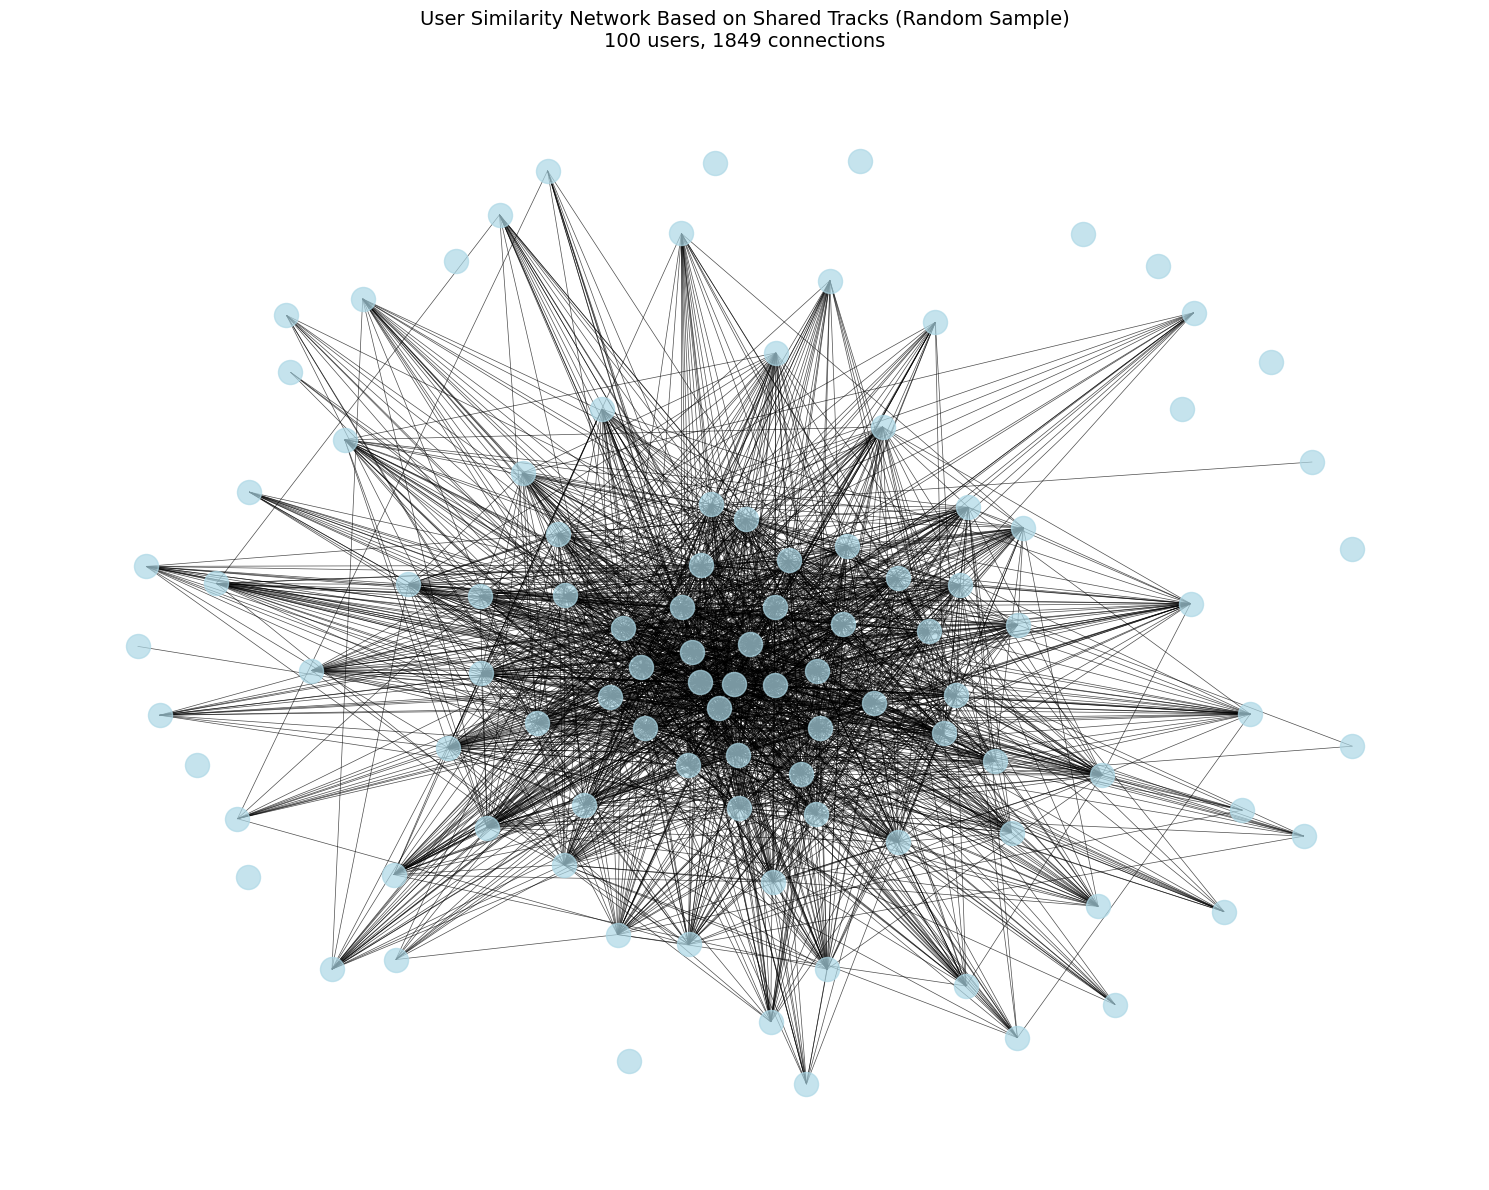


Network Statistics:
- Nodes (users): 100
- Edges (connections): 1849
- Average degree: 36.98
- Connected components: 12
- Average shared tracks per connection: 10.15
- Max shared tracks between any two users: 450
- Most connected user: 5bec076865f710a6314a93765c324633 with 85 connections
- Isolated users (no connections): 11 out of 100 users (11.0%)


In [56]:
# Visualize the network
plt.figure(figsize=(15, 12))

# Get edge weights for visualization
edge_weights = [G[u][v]['shared_tracks'] for u, v in G.edges()]

# Position nodes using force-directed layout
pos = nx.spring_layout(G, k=3, iterations=50)

# Draw the network
nx.draw_networkx_nodes(G, pos, 
                      node_color='lightblue', 
                      node_size=300, 
                      alpha=0.7)

nx.draw_networkx_edges(G, pos, 
                      width=.5,  # Scale edge width by shared tracks (made thicker)
                      alpha=0.7, 
                      edge_color='black')

# Add labels for a subset of nodes (to avoid overcrowding)
if len(G.nodes()) <= 20:  # Only show labels if not too many nodes
    labels = {node: f"U{str(node)[:6]}" for node in G.nodes()}  # Truncate user IDs
    nx.draw_networkx_labels(G, pos, labels, font_size=8)

plt.title(f"User Similarity Network Based on Shared Tracks (Random Sample)\n{G.number_of_nodes()} users, {G.number_of_edges()} connections", 
          fontsize=14, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

# Network statistics
print(f"\nNetwork Statistics:")
print(f"- Nodes (users): {G.number_of_nodes()}")
print(f"- Edges (connections): {G.number_of_edges()}")
print(f"- Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")
print(f"- Connected components: {nx.number_connected_components(G)}")

if G.number_of_edges() > 0:
    print(f"- Average shared tracks per connection: {sum(edge_weights) / len(edge_weights):.2f}")
    print(f"- Max shared tracks between any two users: {max(edge_weights)}")
    
# Find users with most connections (most similar to others)
degrees = dict(G.degree())
if degrees:
    most_connected = max(degrees, key=degrees.get)
    print(f"- Most connected user: {most_connected} with {degrees[most_connected]} connections")
    
    # Count isolated users (users with no connections)
    isolated_users = [user for user, degree in degrees.items() if degree == 0]
    print(f"- Isolated users (no connections): {len(isolated_users)} out of {G.number_of_nodes()} users ({len(isolated_users)/G.number_of_nodes()*100:.1f}%)")